# Do CNNs Really Understand Images or Just Textures? A Study Using Image Distortions
Repository:https://github.com/kowshikrepalle/24154830
## Aim
This notebook tests whether a CNN depends heavily on texture-like image details by evaluating it on distorted images.

## Distortions used
- Blur
- Noise
- Edge-only

## Dataset
Fashion-MNIST

In [24]:
# If needed:
# !pip install torch torchvision matplotlib numpy scipy scikit-image

## Import libraries

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from skimage import feature

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms

## Set device

In [26]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## Load Fashion-MNIST

In [27]:
transform = transforms.ToTensor()

train_full = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_full = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

# Smaller subset for faster training
train_idx = np.random.choice(len(train_full), 12000, replace=False)
test_idx = np.random.choice(len(test_full), 3000, replace=False)

train_base = Subset(train_full, train_idx)
test_base = Subset(test_full, test_idx)

## Define class names

In [28]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

## Show sample images

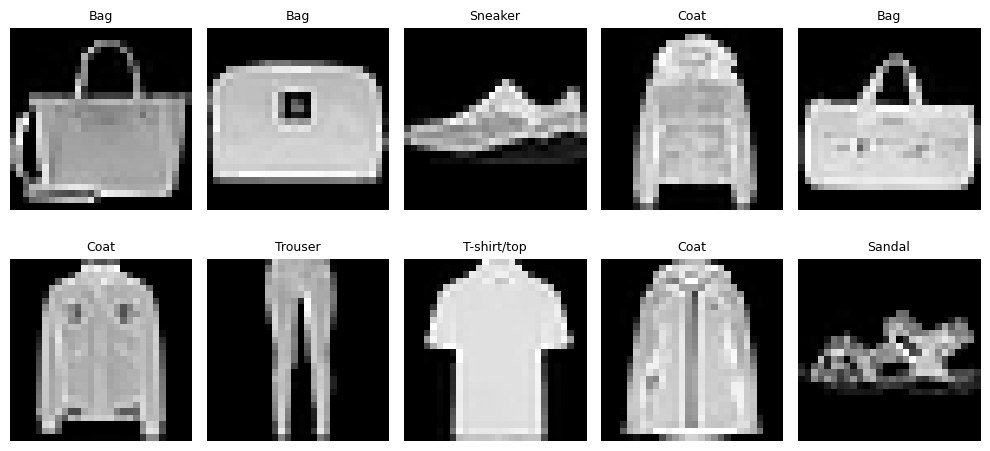

In [29]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flatten()):
    img, label = train_base[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(class_names[label], fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Define image distortions

In [30]:
def blur_image(img, sigma=1.2):
    arr = img.squeeze().numpy()
    arr = gaussian_filter(arr, sigma=sigma)
    return torch.tensor(arr, dtype=torch.float32).unsqueeze(0)

def noise_image(img, std=0.35):
    arr = img.squeeze().numpy()
    noise = np.random.normal(0, std, arr.shape)
    arr = np.clip(arr + noise, 0, 1)
    return torch.tensor(arr, dtype=torch.float32).unsqueeze(0)

def edge_image(img, sigma=1.0):
    arr = img.squeeze().numpy()
    arr = feature.canny(arr, sigma=sigma).astype(np.float32)
    return torch.tensor(arr, dtype=torch.float32).unsqueeze(0)

## Create distorted dataset wrapper

In [31]:
class DistortedDataset(Dataset):
    def __init__(self, base_dataset, distortion=None):
        self.base_dataset = base_dataset
        self.distortion = distortion

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, label = self.base_dataset[idx]

        if self.distortion == "blur":
            img = blur_image(img)
        elif self.distortion == "noise":
            img = noise_image(img)
        elif self.distortion == "edge":
            img = edge_image(img)

        return img, label

## Create training and test datasets

In [32]:
train_dataset = DistortedDataset(train_base, distortion=None)

test_original = DistortedDataset(test_base, distortion=None)
test_blur = DistortedDataset(test_base, distortion="blur")
test_noise = DistortedDataset(test_base, distortion="noise")
test_edge = DistortedDataset(test_base, distortion="edge")

## Show one image under different distortions

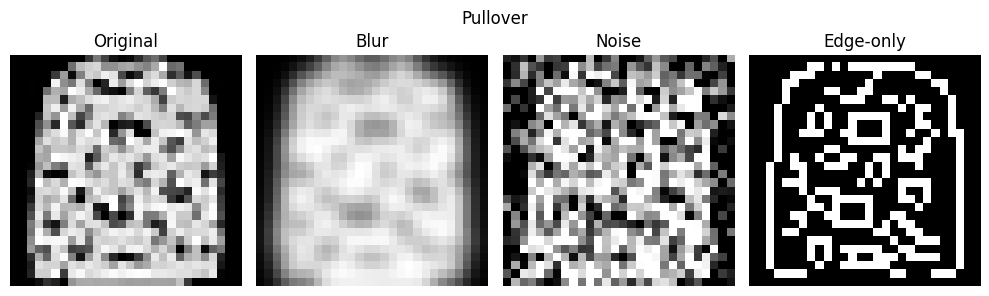

In [33]:
img, label = test_base[0]

img_blur = blur_image(img)
img_noise = noise_image(img)
img_edge = edge_image(img)

fig, axes = plt.subplots(1, 4, figsize=(10, 3))

axes[0].imshow(img.squeeze(), cmap="gray")
axes[0].set_title("Original")

axes[1].imshow(img_blur.squeeze(), cmap="gray")
axes[1].set_title("Blur")

axes[2].imshow(img_noise.squeeze(), cmap="gray")
axes[2].set_title("Noise")

axes[3].imshow(img_edge.squeeze(), cmap="gray")
axes[3].set_title("Edge-only")

for ax in axes:
    ax.axis("off")

plt.suptitle(class_names[label])
plt.tight_layout()
plt.show()

## Create data loaders

In [34]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader_original = DataLoader(test_original, batch_size=batch_size, shuffle=False)
test_loader_blur = DataLoader(test_blur, batch_size=batch_size, shuffle=False)
test_loader_noise = DataLoader(test_noise, batch_size=batch_size, shuffle=False)
test_loader_edge = DataLoader(test_edge, batch_size=batch_size, shuffle=False)

## Define CNN model

In [35]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

## Initialise model

In [36]:
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Train the model

In [37]:
epochs = 5
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = total_loss / total
    epoch_acc = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.4f}")

Epoch 1/5 - Loss: 0.8675 - Accuracy: 0.6875
Epoch 2/5 - Loss: 0.5208 - Accuracy: 0.8069
Epoch 3/5 - Loss: 0.4461 - Accuracy: 0.8371
Epoch 4/5 - Loss: 0.3936 - Accuracy: 0.8567
Epoch 5/5 - Loss: 0.3555 - Accuracy: 0.8684


## Plot training loss and accuracy

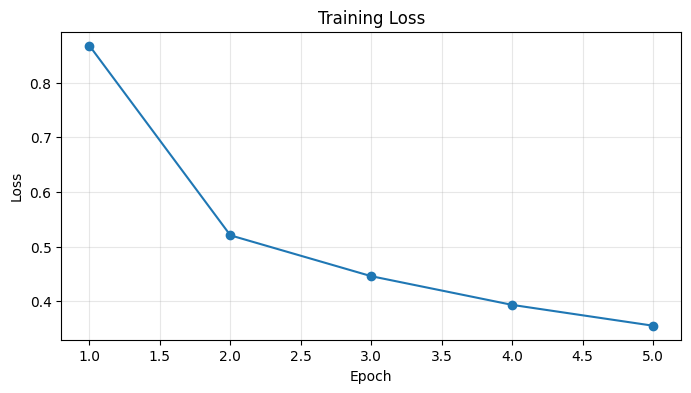

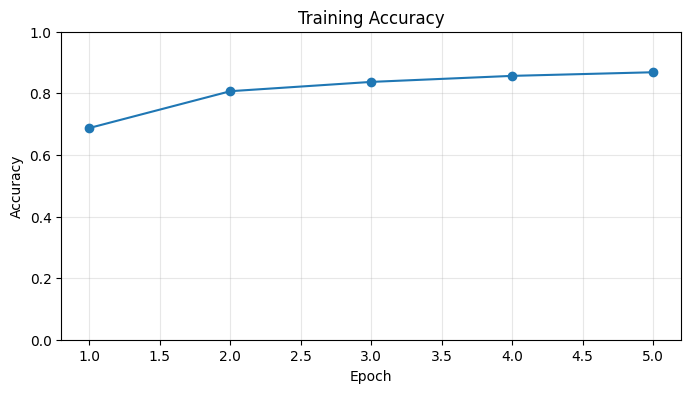

In [38]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs + 1), train_losses, marker="o")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs + 1), train_accuracies, marker="o")
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.show()

## Evaluate the model

In [39]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

In [40]:
acc_original = evaluate(model, test_loader_original)
acc_blur = evaluate(model, test_loader_blur)
acc_noise = evaluate(model, test_loader_noise)
acc_edge = evaluate(model, test_loader_edge)

print("Original:", round(acc_original, 4))
print("Blur:", round(acc_blur, 4))
print("Noise:", round(acc_noise, 4))
print("Edge-only:", round(acc_edge, 4))

Original: 0.861
Blur: 0.778
Noise: 0.3633
Edge-only: 0.426


## Compare results

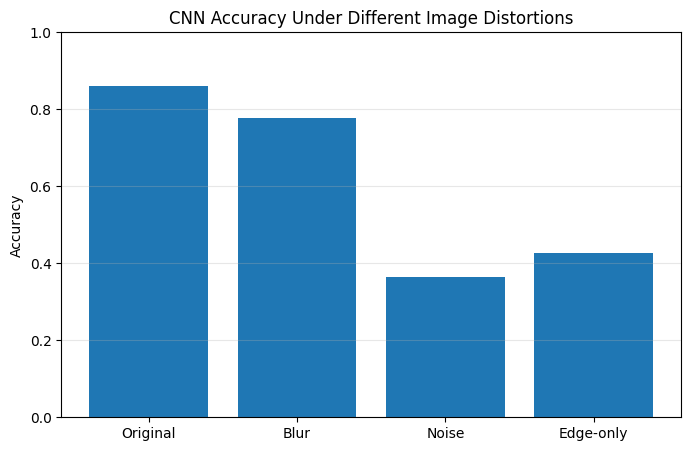

In [41]:
conditions = ["Original", "Blur", "Noise", "Edge-only"]
accuracies = [acc_original, acc_blur, acc_noise, acc_edge]

plt.figure(figsize=(8, 5))
plt.bar(conditions, accuracies)
plt.title("CNN Accuracy Under Different Image Distortions")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.show()

## Accuracy Drop Due to Distortions

This graph shows how much the CNN performance decreases compared to original images.

A larger drop indicates that the model depends more on texture and fine details.

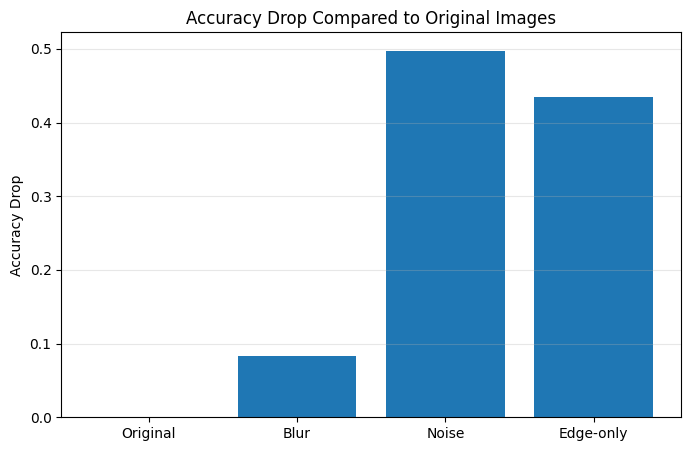

In [42]:
# Calculate accuracy drop
drop_blur = acc_original - acc_blur
drop_noise = acc_original - acc_noise
drop_edge = acc_original - acc_edge

drops = [0, drop_blur, drop_noise, drop_edge]
labels = ["Original", "Blur", "Noise", "Edge-only"]

plt.figure(figsize=(8, 5))
plt.bar(labels, drops)
plt.title("Accuracy Drop Compared to Original Images")
plt.ylabel("Accuracy Drop")
plt.grid(axis="y", alpha=0.3)
plt.show()

## Confusion Matrix Analysis

The confusion matrix shows how the CNN classifies each category and where it makes mistakes.

This helps us understand which classes are most affected by distortions.

In [43]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import torch

def plot_confusion_matrix(model, loader, class_names, title):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, cmap="viridis")
    plt.title(title)
    plt.colorbar()

    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha="right")
    plt.yticks(ticks, class_names)

    plt.xlabel("Predicted")
    plt.ylabel("True")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center", color="white", fontsize=8)

    plt.tight_layout()
    plt.show()

    return cm

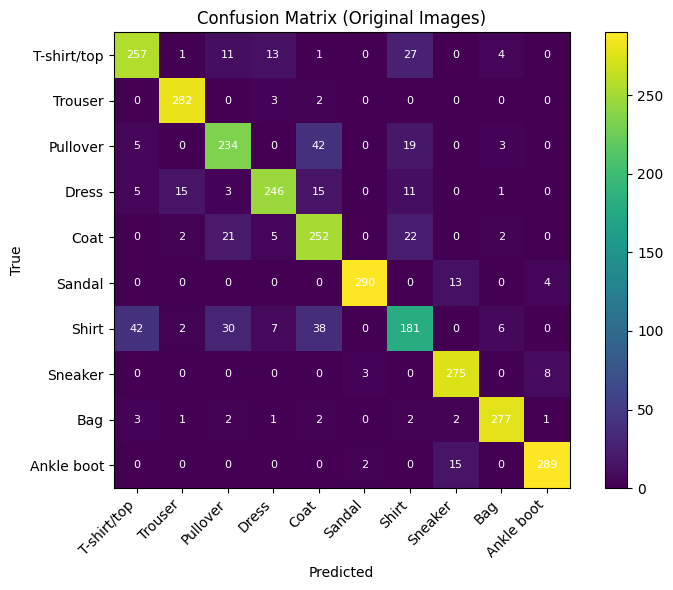

In [44]:
cm_original = plot_confusion_matrix(
    model,
    test_loader_original,
    class_names,
    "Confusion Matrix (Original Images)"
)

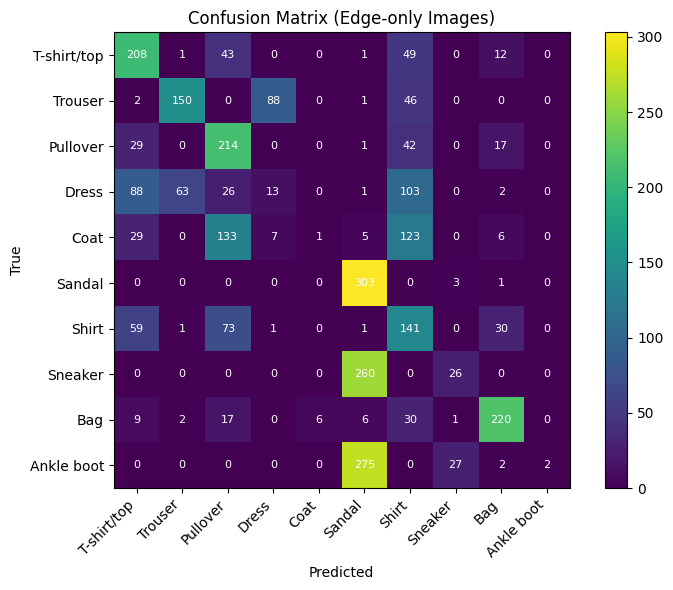

In [45]:
cm_edge = plot_confusion_matrix(
    model,
    test_loader_edge,
    class_names,
    "Confusion Matrix (Edge-only Images)"
)

## Summary table

In [46]:
import pandas as pd

results = pd.DataFrame({
    "Condition": conditions,
    "Accuracy": accuracies
})

results

,Condition,Accuracy
0,Original,0.861000
1,Blur,0.778000
2,Noise,0.363333
3,Edge-only,0.426000


## Conclusion

If the model performs much worse on blurred, noisy, or edge-only images, this suggests that CNN classification depends strongly on local visual details such as texture and sharp patterns.

A smaller drop would suggest that the CNN has learned more robust object-level structure.

REFERENCES:

LeCun, Y., Bengio, Y. and Hinton, G. (2015) ‘Deep learning’, Nature, 521(7553), pp. 436–444.

Geirhos, R. et al. (2019) ‘ImageNet-trained CNNs are biased towards texture rather than shape’, ICLR. Available at: https://arxiv.org/abs/1811.12231

Xiao, H., Rasul, K. and Vollgraf, R. (2017) ‘Fashion-MNIST: a novel image dataset for benchmarking machine learning algorithms’. Available at: https://github.com/zalandoresearch/fashion-mnist

Paszke, A. et al. (2019) ‘PyTorch: An imperative style, high-performance deep learning library’, NeurIPS.

Pedregosa, F. et al. (2011) ‘Scikit-learn: Machine learning in Python’, Journal of Machine Learning Research, 12, pp. 2825–2830.

Van der Walt, S. et al. (2014) ‘scikit-image: image processing in Python’, PeerJ, 2, p. e453.